In [197]:
import os

DATASET_PATH = r"C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VALIDATION_PATH = os.path.join(DATASET_PATH, "validation")

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Train exists:", os.path.exists(TRAIN_PATH))
print("Validation exists:", os.path.exists(VALIDATION_PATH))

Dataset exists: True
Train exists: True
Validation exists: True


In [198]:
print("\nTrain folders:")
print(os.listdir(TRAIN_PATH))

print("\nValidation folders:")
print(os.listdir(VALIDATION_PATH))


Train folders:
['no', 'yes']

Validation folders:
['no', 'yes']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dense,
    Flatten
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model

In [200]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

# Training data:
# Normalize images + apply augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    vertical_flip=True
)

# Validation data:
# Normalize only — no augmentation
validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [201]:

# ============================================================
# TRAINING DATA
# ============================================================

training_set = train_datagen.flow_from_directory(
    directory=TRAIN_PATH,
    target_size=(256, 256),
    batch_size=16,
    class_mode="binary",
    shuffle=True,
    seed=42
)


Found 1792 images belonging to 2 classes.


In [202]:
# ============================================================
# VALIDATION DATA
# ============================================================

validation_set = validation_datagen.flow_from_directory(
    directory=VALIDATION_PATH,
    target_size=(256, 256),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)


Found 1208 images belonging to 2 classes.


In [203]:

# ============================================================
# DATASET INFORMATION
# ============================================================

print("\nClass indices:", training_set.class_indices)
print("Training samples:", training_set.samples)
print("Validation samples:", validation_set.samples)


Class indices: {'no': 0, 'yes': 1}
Training samples: 1792
Validation samples: 1208


In [204]:
# create CNN model

model = Sequential()

    # Block 1
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

    # Block 2
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

    # Block 3
model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

    # Block 4
model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

    # Classification head
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\drish\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [205]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,478,465 (13.27 MB)

 Trainable params: 3,477,761 (13.27 MB)

 Non-trainable params: 704 (2.75 KB)

In [206]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [207]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [209]:
H = model.fit(
    training_set,
    epochs=40,
    validation_data=validation_set,
    verbose=1,
    shuffle=True
)

Epoch 1/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9978 - loss: 0.0091 - val_accuracy: 0.9495 - val_loss: 0.2102
Epoch 2/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9961 - loss: 0.0105 - val_accuracy: 0.9661 - val_loss: 0.1547
Epoch 3/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9978 - loss: 0.0058 - val_accuracy: 0.9503 - val_loss: 0.2759
Epoch 4/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9685 - val_loss: 0.1911
Epoch 5/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 1.0000 - loss: 3.8493e-04 - val_accuracy: 0.9669 - val_loss: 0.1939
Epoch 6/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 1.0000 - loss: 4.8066e-04 - val_accuracy: 0.9694 - val_loss: 0.1855
Epoch 7/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9994 - loss: 0.0011 - val_accuracy: 0.9743 - val_loss: 0.1712
Epoch 8/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9760 - loss: 0.0779 - 

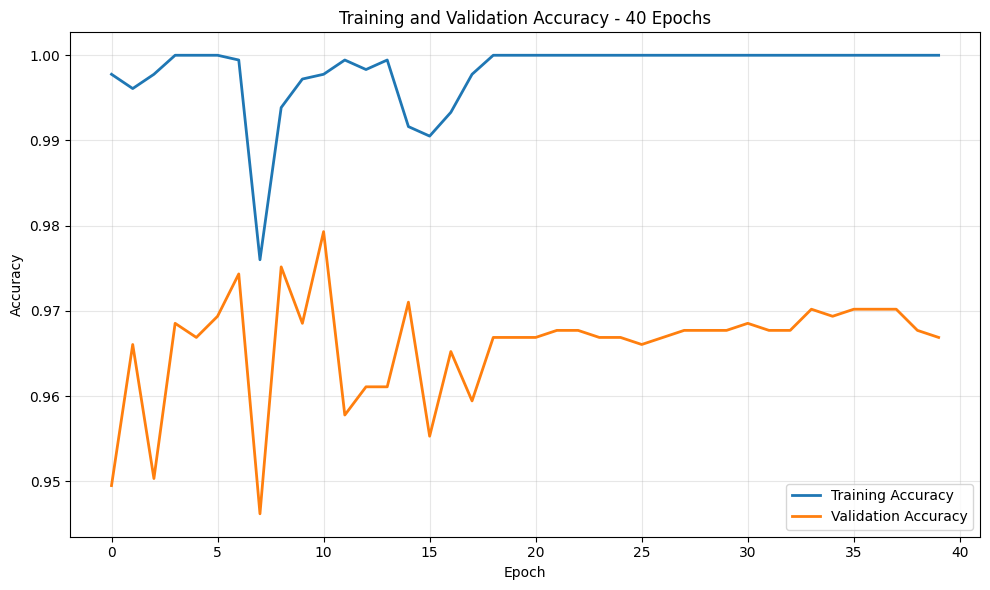

In [210]:
# ============================================================
# TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(H.history["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(H.history["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy - 40 Epochs")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

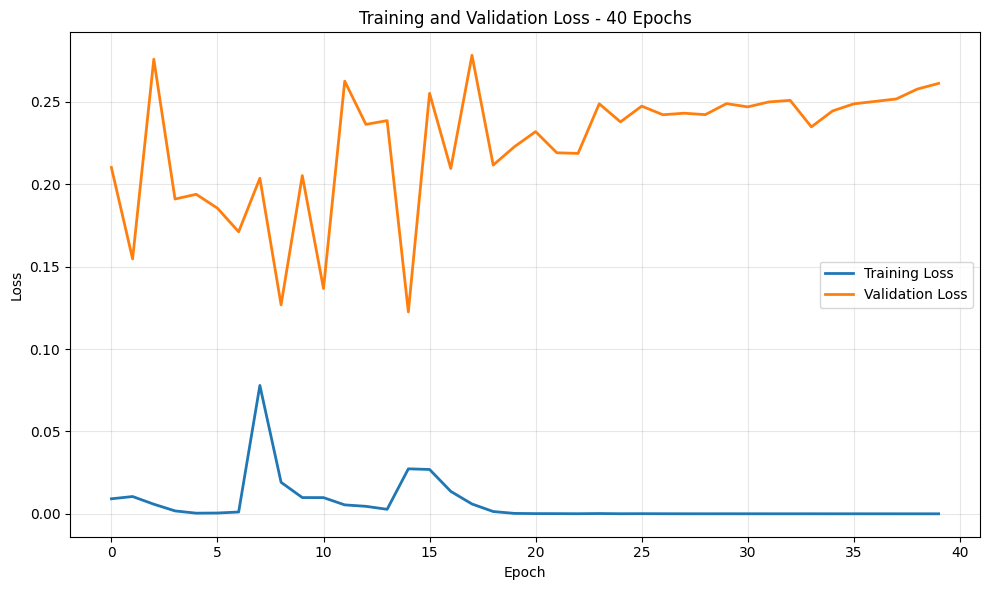

In [211]:
# ============================================================
# TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(H.history["loss"], label="Training Loss", linewidth=2)
plt.plot(H.history["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - 40 Epochs")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [212]:
# ============================================================
# RESTORE FINAL SAVED MODEL
# ============================================================

model = load_model("./Modelcnn.keras")

print("Final saved model restored successfully.")

Final saved model restored successfully.


In [213]:
# ============================================================
# VALIDATION PREDICTIONS
# ============================================================

validation_set.reset()

validation_probabilities = model.predict(
    validation_set,
    verbose=1
)

validation_predictions = (
    validation_probabilities.ravel() >= 0.15
).astype(int)

validation_true_labels = validation_set.classes

76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step


In [214]:
# ============================================================
# VALIDATION CLASSIFICATION REPORT
# ============================================================
print("Number of true labels:", len(validation_true_labels))
print("Number of predictions:", len(validation_predictions))

Number of true labels: 1208
Number of predictions: 1208


In [215]:
print(
    classification_report(
        validation_true_labels,
        validation_predictions,
        target_names=["No Tumor", "Tumor"],
        digits=4
    )
)

              precision    recall  f1-score   support

    No Tumor     0.9595    0.9948    0.9768       572
       Tumor     0.9951    0.9623    0.9784       636

    accuracy                         0.9776      1208
   macro avg     0.9773    0.9785    0.9776      1208
weighted avg     0.9783    0.9776    0.9777      1208



Confusion Matrix:
[[566   6]
 [ 21 615]]


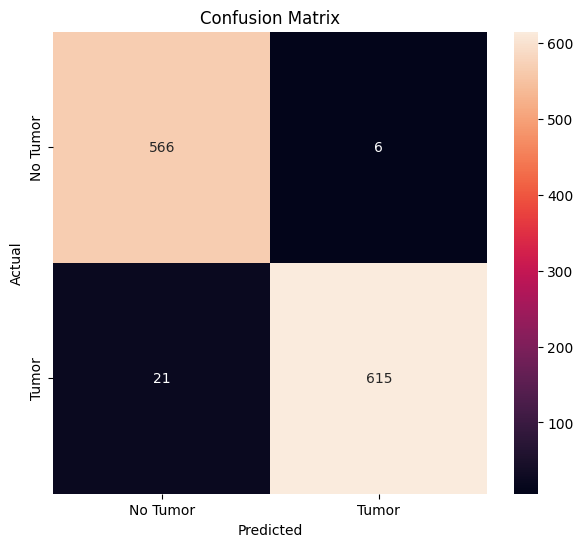

In [ ]:
# ============================================================
# VALIDATION CONFUSION MATRIX
# ============================================================

valiadtion_cm = confusion_matrix(
    validation_true_labels,
    validation_predictions
)

print("Validation Confusion Matrix:")
print(valiadtion_cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    valiadtion_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Tumor", "Tumor"],
    yticklabels=["No Tumor", "Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.show()

In [216]:
# ============================================================
# FIND MISCLASSIFIED IMAGES
# ============================================================

# Get file paths in the same order as validation_set
image_paths = validation_set.filepaths

# False negatives:
# Actual = Tumor (1)
# Predicted = No Tumor (0)

false_negative_indices = np.where(
    (validation_true_labels == 1) & (validation_predictions == 0)
)[0]

print("Number of false negatives:", len(false_negative_indices))

for idx in false_negative_indices[:10]:
    print(image_paths[idx])

Number of false negatives: 24
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1271.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1274.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1275.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1284.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1362.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1366.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1368.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1379.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1382.jpg
C:\Users\drish\Documents\Projects\Brain Tumor detection model\archive_3\validation\yes\y1383.jpg


Number of false negatives: 24


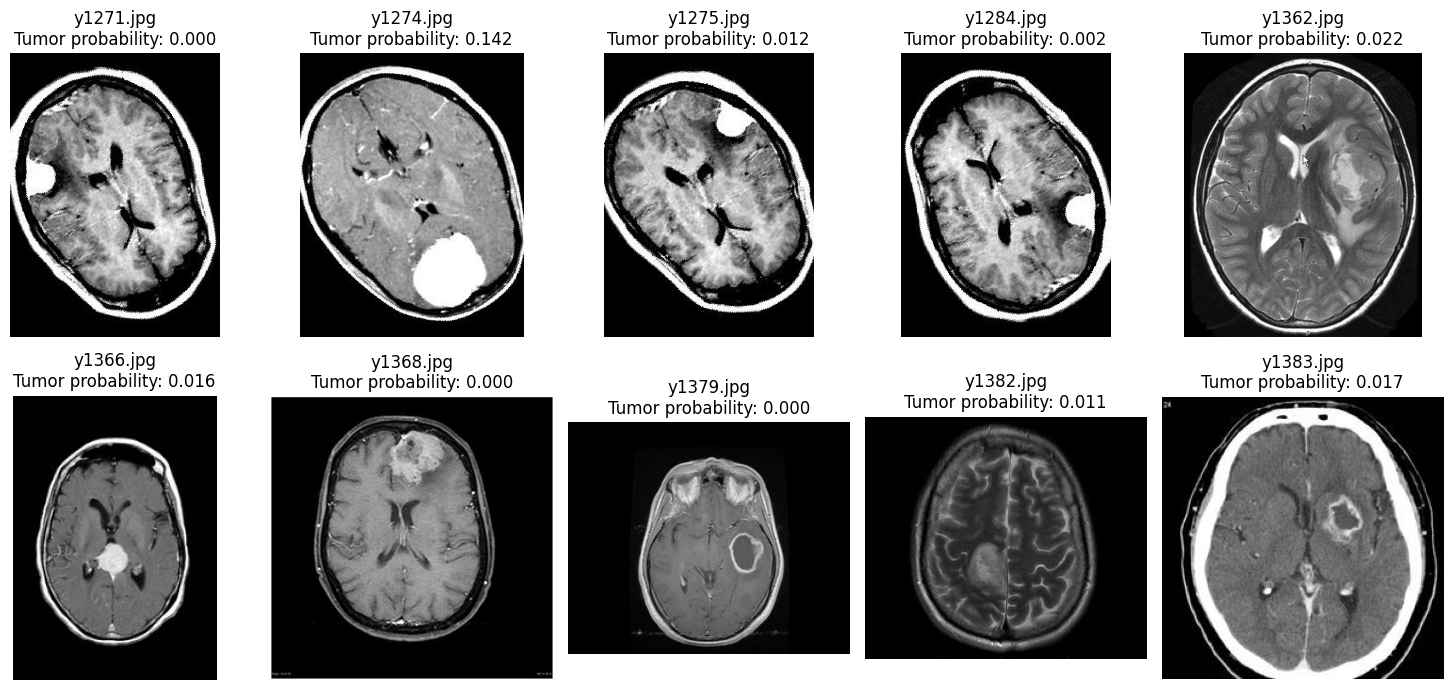

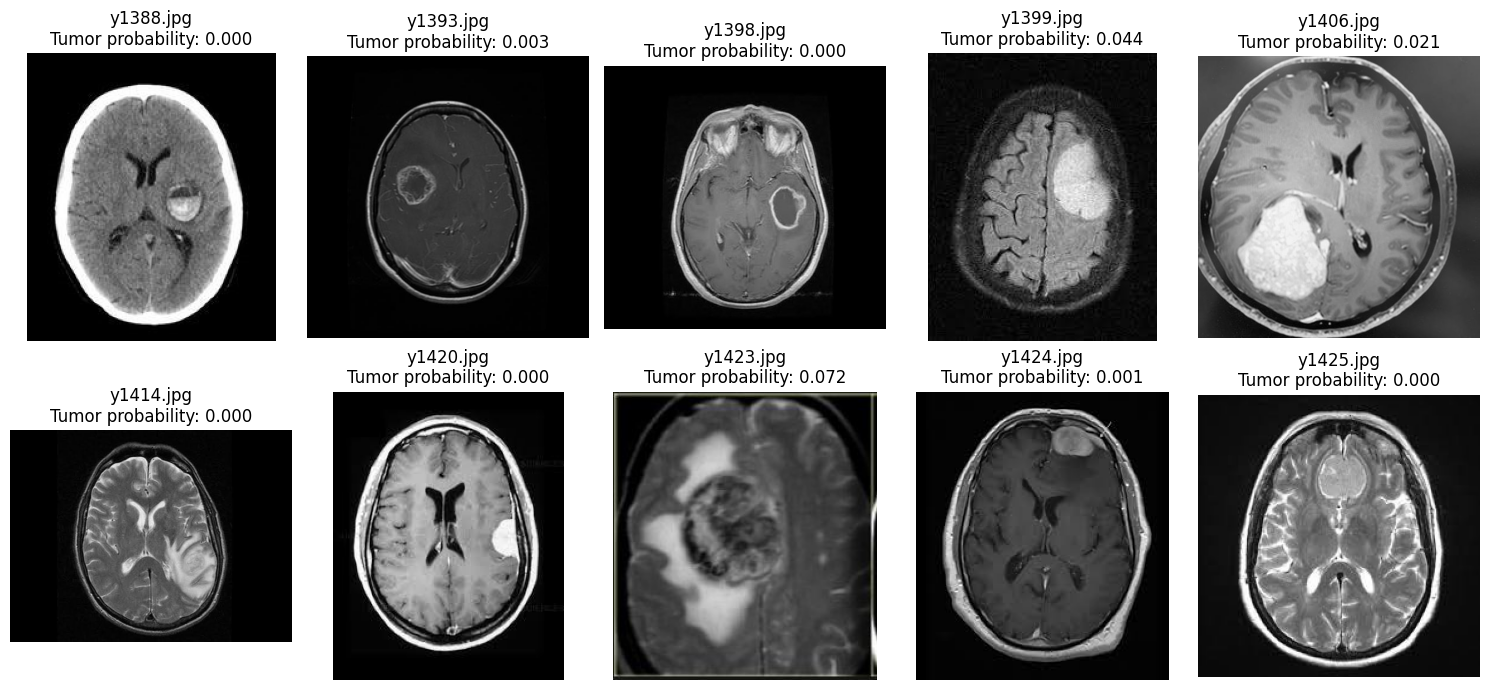

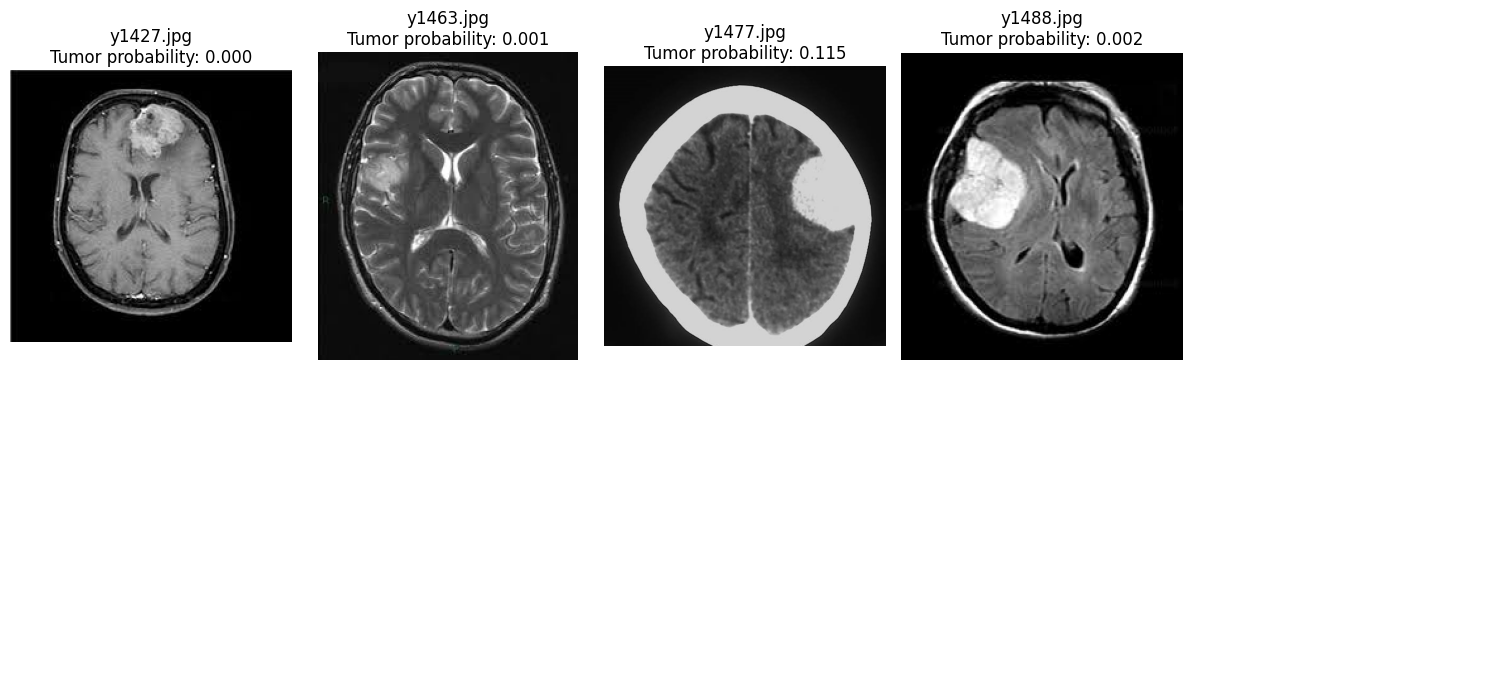

In [ ]:
from PIL import Image
import math

# ============================================================
# FALSE-NEGATIVE IMAGES
# Actual = Tumor
# Predicted = No Tumor
# ============================================================

print("Number of false negatives:", len(false_negative_indices))

# Display 10 at a time
for start in range(0, len(false_negative_indices), 10):

    batch_indices = false_negative_indices[start:start + 10]

    fig, axes = plt.subplots(
        2, 5,
        figsize=(15, 7)
    )

    axes = axes.flatten()

    for ax, idx in zip(axes, batch_indices):

        image_path = validation_set.filepaths[idx]
        image = Image.open(image_path)

        tumor_probability = validation_probabilities[idx][0]

        ax.imshow(image, cmap="gray")
        ax.axis("off")

        ax.set_title(
            f"{os.path.basename(image_path)}\n"
            f"Tumor probability: {tumor_probability:.3f}"
        )

    for ax in axes[len(batch_indices):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [218]:
# ============================================================
# FALSE-NEGATIVE PROBABILITY TABLE
# ============================================================

false_negative_data = pd.DataFrame({

    "filename": [
        os.path.basename(validation_set.filepaths[i])
        for i in false_negative_indices
    ],

    "probability": [
        float(validation_probabilities[i][0])
        for i in false_negative_indices
    ]

})

print(false_negative_data.to_string(index=False))

 filename  probability
y1271.jpg 3.219761e-04
y1274.jpg 1.424775e-01
y1275.jpg 1.168611e-02
y1284.jpg 2.417987e-03
y1362.jpg 2.235468e-02
y1366.jpg 1.574564e-02
y1368.jpg 9.288880e-05
y1379.jpg 5.150870e-08
y1382.jpg 1.095662e-02
y1383.jpg 1.664057e-02
y1388.jpg 6.066926e-06
y1393.jpg 3.397044e-03
y1398.jpg 2.209014e-07
y1399.jpg 4.403961e-02
y1406.jpg 2.137065e-02
y1414.jpg 1.895067e-10
y1420.jpg 6.246623e-11
y1423.jpg 7.225948e-02
y1424.jpg 1.494617e-03
y1425.jpg 3.102622e-04
y1427.jpg 6.132224e-07
y1463.jpg 5.995210e-04
y1477.jpg 1.153708e-01
y1488.jpg 1.642621e-03


In [ ]:
from collections import Counter

# Training class distribution
train_counts = Counter(training_set.classes)

# Validation class distribution
validation_counts = Counter(validation_set.classes)

print("Training class distribution:")
print(train_counts)

print("\nValidation class distribution:")
print(validation_counts)

Training class distribution:
Counter({np.int32(0): 928, np.int32(1): 864})

Validation class distribution:
Counter({np.int32(1): 636, np.int32(0): 572})


In [ ]:
import os

VALIDATION2_PATH = os.path.join(
    DATASET_PATH,
    "validation2"
)

print("Validation2 exists:", os.path.exists(VALIDATION2_PATH))

print("\nFolders:")
print(os.listdir(VALIDATION2_PATH))

Validation2 exists: True

Folders:
['no', 'yes']


In [ ]:
for class_name in os.listdir(VALIDATION2_PATH):
    class_path = os.path.join(VALIDATION2_PATH, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        print(
            f"{class_name}: {len(images)} images"
        )

no: 50 images
yes: 50 images


In [ ]:
# ============================================================
# FINAL TEST SET
# ============================================================

test_data = validation_datagen.flow_from_directory(
    VALIDATION2_PATH,
    target_size=(256, 256),
    batch_size=16,
    shuffle=False,
    class_mode="binary"
)

Found 100 images belonging to 2 classes.


In [223]:
# ============================================================
# FINAL TEST PREDICTIONS
# ============================================================

test_data.reset()
predicted_probabilities = model.predict(
    test_data,
    verbose=1
)

predicted_labels = (
    predicted_probabilities.ravel() >= 0.15
).astype(int)

true_labels = test_data.classes

print("Number of test labels:", len(true_labels))
print("Number of test predictions:", len(predicted_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step
Number of test labels: 100
Number of test predictions: 100


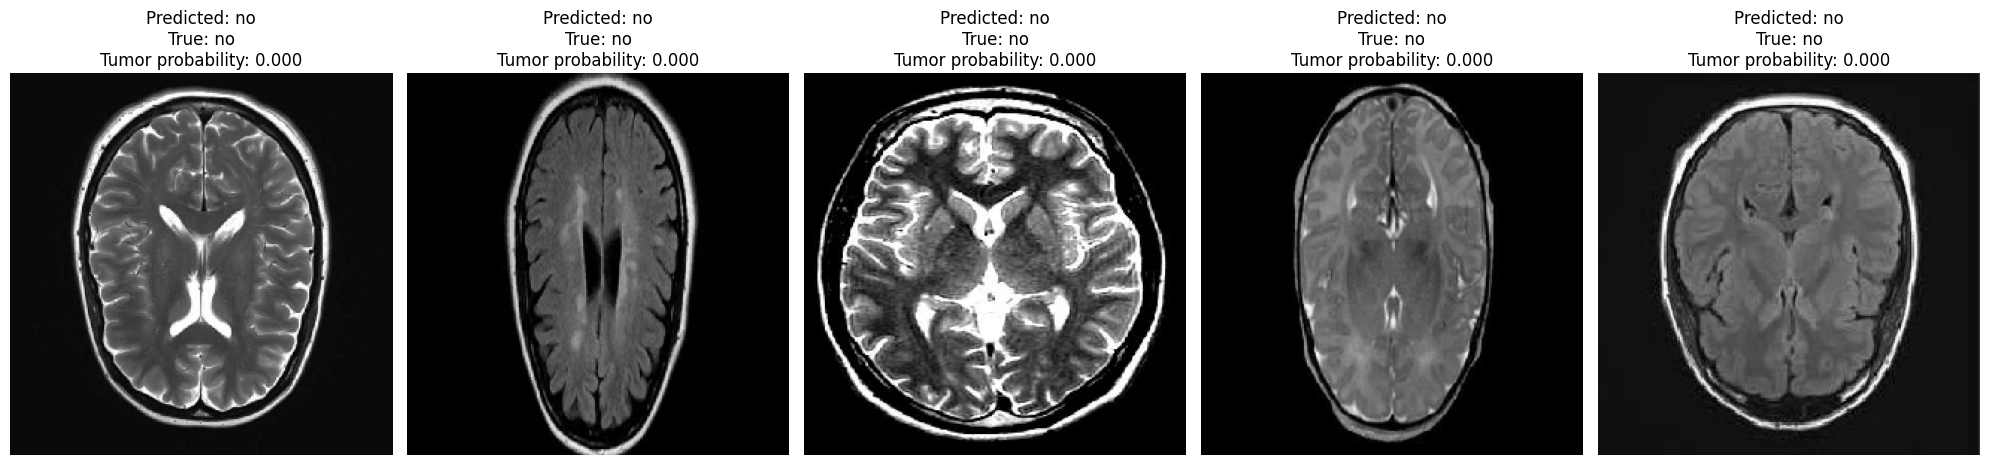

In [224]:
# ============================================================
# TEST PREDICTION IMAGES
# ============================================================

num_images = 5

test_data.reset()

test_data_batch = next(test_data)
test_images = test_data_batch[0]
test_batch_labels = test_data_batch[1]

class_names = list(test_data.class_indices.keys())

true_class_names = [
    class_names[int(label)]
    for label in test_batch_labels
]

predicted_class_names = [
    class_names[int(label)]
    for label in predicted_labels[:num_images]
]

predicted_probabilities_display = predicted_probabilities[:num_images]

# Plot the images with predicted and true labels
fig, axes = plt.subplots(
    1,
    num_images,
    figsize=(20, 5)
)

for i, ax in enumerate(axes):

    ax.imshow(test_images[i])
    ax.axis("off")

    ax.set_title(
        f"Predicted: {predicted_class_names[i]}\n"
        f"True: {true_class_names[i]}\n"
        f"Tumor probability: {predicted_probabilities_display[i][0]:.3f}"
    )

plt.tight_layout()
plt.show()

In [225]:
# ============================================================
# FINAL TEST SET EVALUATION
# ============================================================

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["No Tumor", "Tumor"],
        digits=4
    )
)


              precision    recall  f1-score   support

    No Tumor     1.0000    1.0000    1.0000        50
       Tumor     1.0000    1.0000    1.0000        50

    accuracy                         1.0000       100
   macro avg     1.0000    1.0000    1.0000       100
weighted avg     1.0000    1.0000    1.0000       100



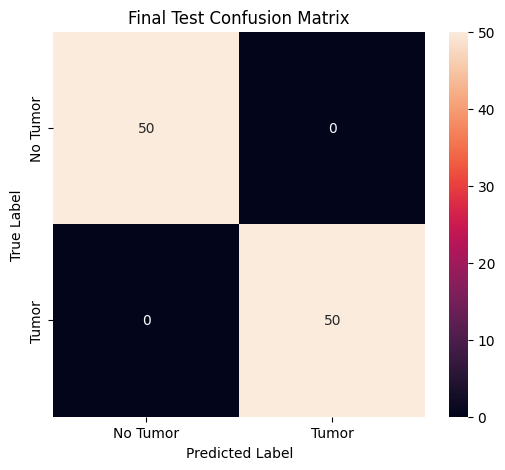

In [ ]:
# ============================================================
# FINAL TEST CONFUSION MATRIX VISUALIZATION
# ============================================================
# ============================================================
# FINAL TEST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Tumor", "Tumor"],
    yticklabels=["No Tumor", "Tumor"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Test Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

test_accuracy = np.mean(
    true_labels == predicted_labels
)

false_positives = np.sum(
    (true_labels == 0) & (predicted_labels == 1)
)

false_negatives = np.sum(
    (true_labels == 1) & (predicted_labels == 0)
)

print(f"Final Test Accuracy: {test_accuracy:.4%}")
print(f"Test Images: {len(true_labels)}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

Final Test Accuracy: 100.0000%
Test Images: 100
False Positives: 0
False Negatives: 0


In [ ]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

model.save("./Modelcnn.keras")

print("Final model saved successfully.")

Final model saved successfully.
